In [2]:
import ipywidgets as widgets
from IPython.display import display
import os

box_layout = widgets.Layout(
    display="flex",
    flex_flow="column",
    align_items="center",
    border="1px solid #E0E0E0",
    width="400px",
    padding="25px",
    border_radius="10px"
)

button_layout = widgets.Layout(width="100%", height="40px")

upload_layout = widgets.Layout(width="100%")

title = widgets.HTML(
    "<h3 style='margin-bottom:10px;'>Upload CSV Files 👇</h3>"
)

subtitle = widgets.HTML(
    "<p style='color:gray; margin-top:0;'>Select one or more CSV files to upload and save</p>"
)

train_uploader = widgets.FileUpload(
    accept='.csv',
    multiple=True,
    layout=upload_layout
)

save_button = widgets.Button(
    description='Save Files',
    button_style='primary',
    icon='save',
    layout=button_layout
)

status = widgets.HTML("<p style='color:gray;'>Waiting for upload...</p>")

output = widgets.Output()

def save_files(change=None):
    with output:
        output.clear_output()
        
        if train_uploader.value:
            saved_files = []
            for filename, file_info in train_uploader.value.items():
                with open(filename, "wb") as f:
                    f.write(file_info['content'])
                saved_files.append(filename)
            
            status.value = f"<p style='color:green;'>Saved {len(saved_files)} file(s) 👍</p>"
        else:
            status.value = "<p style='color:red;'>⚠️ No files uploaded yet</p>"

train_uploader.observe(save_files, names='value')

save_button.on_click(save_files)

card = widgets.VBox(
    [title, subtitle, train_uploader, save_button, status],
    layout=box_layout
)

display(card)
display(output)

Output()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sb

In [3]:
df = pd.read_csv('data.csv')

In [4]:
df.sample(4)

,feature1,feature2,feature3,target
99,-0.430890,-0.540270,-0.648432,-48.947507
134,-0.282505,0.964966,0.256560,-23.669427
64,1.719477,-2.359215,0.166520,135.673910
150,1.518692,0.896356,-0.611353,84.617998


In [5]:
x = df.iloc[:, 0:3].values
y = df.iloc[:, -1].values

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=1
)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
reg = LinearRegression()

In [10]:
reg.fit(xtrain, ytrain)

LinearRegression()

## **Linear Relationship**

Text(0.5, 1.0, 'Feature 3')

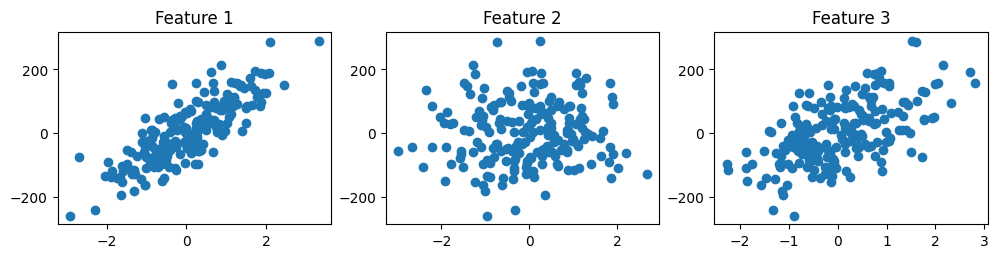

In [11]:
figure, (ax1, ax2, ax3) = plot.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature 1")

ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature 2")

ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature 3")

## **Multicollinerity**

### **Technique 1**
If variance inflation factor >= 5 : multicollineariy exists

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
vif = []

for i in range(xtrain.shape[1]):
    vif.append(variance_inflation_factor(xtrain, i))

In [19]:
pd.DataFrame(
    {'vif' : vif},
    index=df.columns[0:3]
)

,vif
feature1,1.010326
feature2,1.009871
feature3,1.013950


### **Technique 2**

<Axes: >

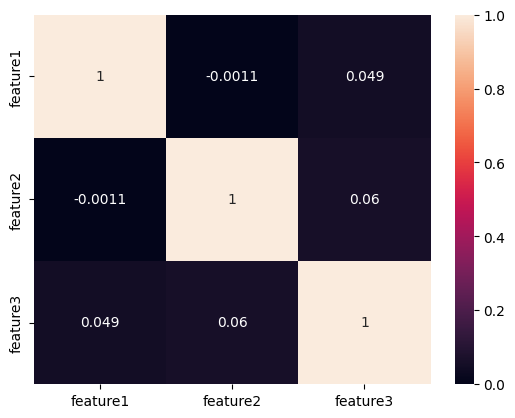

In [20]:
sb.heatmap(df.iloc[:, 0:3].corr(), annot=True)

## **Normality of residual**

In [21]:
y_pred = reg.predict(xtest)

In [22]:
residual = ytest - y_pred

<Axes: ylabel='Density'>

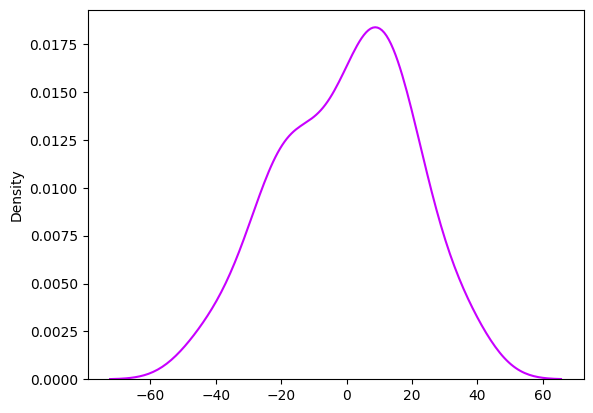

In [24]:
# Directly plotting normal distribution function
sb.kdeplot(residual, color="#c800ff")

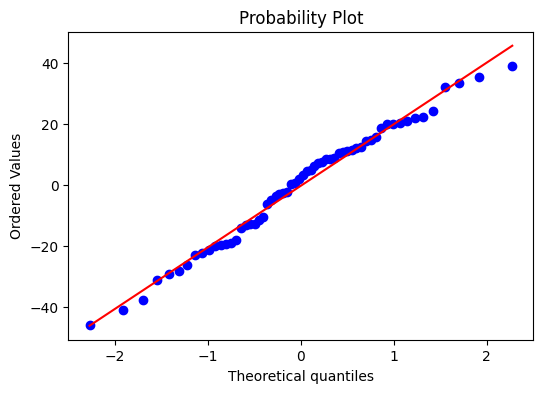

In [26]:
## QQ plot
import scipy as sp

fig, ax = plot.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plot.show()

## **Homoscedasticity**

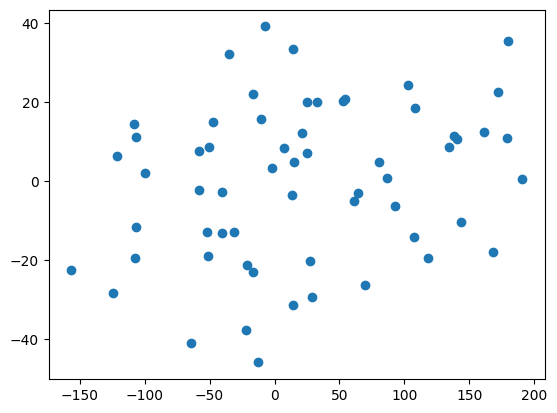

In [27]:
plot.scatter(y_pred, residual)

## **No autocorrelation of errors**

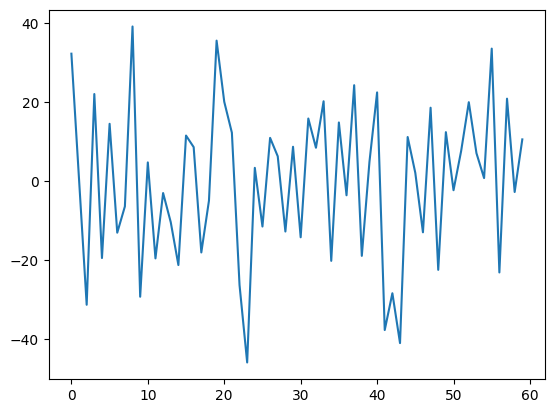

In [28]:
plot.plot(residual)